In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import tree, ensemble, svm
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

import gc; gc.collect()


20

In [2]:
data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

data_train["train_test"] = True
data_test["train_test"] = False

data_merged = pd.concat([data_train, data_test], axis=0, ignore_index=True)

# Exploratory Analysis

In [3]:
data_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5194909 entries, 0 to 5194908
Data columns (total 23 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   class                 object 
 2   cap-diameter          float64
 3   cap-shape             object 
 4   cap-surface           object 
 5   cap-color             object 
 6   does-bruise-or-bleed  object 
 7   gill-attachment       object 
 8   gill-spacing          object 
 9   gill-color            object 
 10  stem-height           float64
 11  stem-width            float64
 12  stem-root             object 
 13  stem-surface          object 
 14  stem-color            object 
 15  veil-type             object 
 16  veil-color            object 
 17  has-ring              object 
 18  ring-type             object 
 19  spore-print-color     object 
 20  habitat               object 
 21  season                object 
 22  train_test            bool   
dtypes: bool

In [4]:
data_train.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,train_test
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,w,NaN,NaN,f,f,NaN,d,a,True
1,1,p,4.51,x,h,o,f,a,c,n,...,y,o,NaN,NaN,t,z,NaN,d,w,True
2,2,e,6.94,f,s,b,f,x,c,w,...,s,n,NaN,NaN,f,f,NaN,l,w,True
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,w,NaN,NaN,f,f,NaN,d,u,True
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,w,NaN,NaN,f,f,NaN,g,a,True


In [5]:
data_train.describe(include='number')

,id,cap-diameter,stem-height,stem-width
count,3.116945e+06,3.116941e+06,3.116945e+06,3.116945e+06
mean,1.558472e+06,6.309848e+00,6.348333e+00,1.115379e+01
std,8.997847e+05,4.657931e+00,2.699755e+00,8.095477e+00
min,0.000000e+00,3.000000e-02,0.000000e+00,0.000000e+00
25%,7.792360e+05,3.320000e+00,4.670000e+00,4.970000e+00
50%,1.558472e+06,5.750000e+00,5.880000e+00,9.650000e+00
75%,2.337708e+06,8.240000e+00,7.410000e+00,1.563000e+01
max,3.116944e+06,8.067000e+01,8.872000e+01,1.029000e+02


In [6]:
data_train.describe(include='O').T

,count,unique,top,freq
class,3116945,2,p,1705396
cap-shape,3116905,74,x,1436026
cap-surface,2445922,83,t,460777
cap-color,3116933,78,n,1359542
does-bruise-or-bleed,3116937,26,f,2569743
gill-attachment,2593009,78,a,646034
gill-spacing,1858510,48,c,1331054
gill-color,3116888,63,w,931538
stem-root,359922,38,b,165801
stem-surface,1136084,60,s,327610


In [7]:

column_numerical = ['cap-diameter', 'stem-height', 'stem-width']
column_categorical = ['class','season', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
                      'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat']


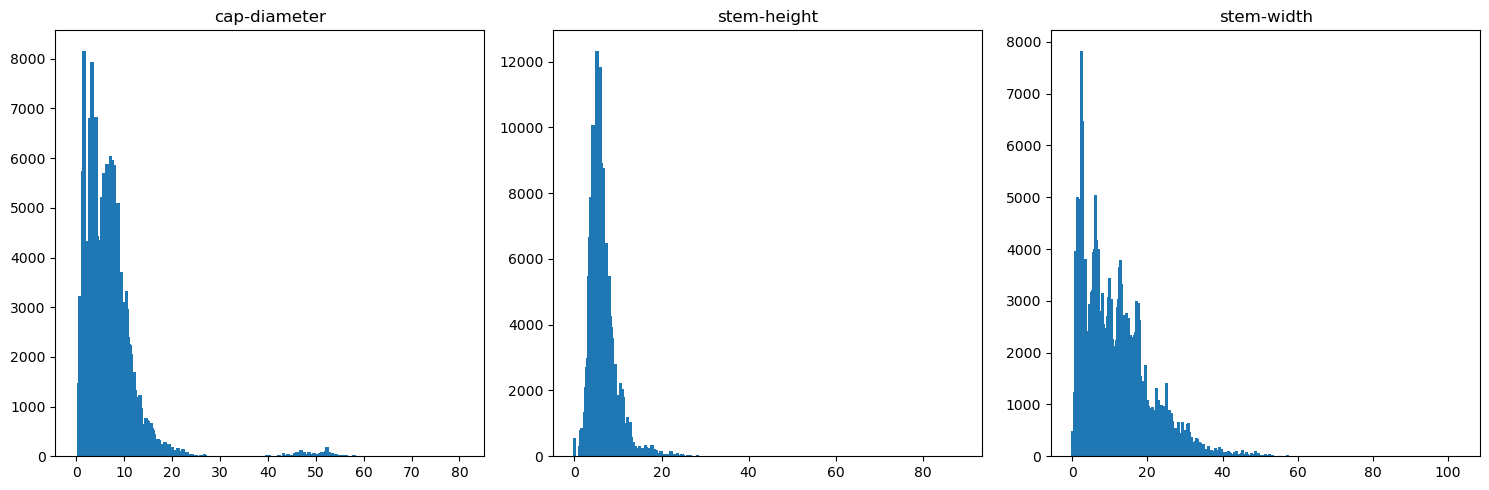

In [8]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax = ax.flatten()
for idx, c in enumerate(column_numerical):
    counts = data_train[c].value_counts()
    ax[idx].bar(counts.index, counts.values)
    ax[idx].set_title(c)

plt.tight_layout()
plt.show()

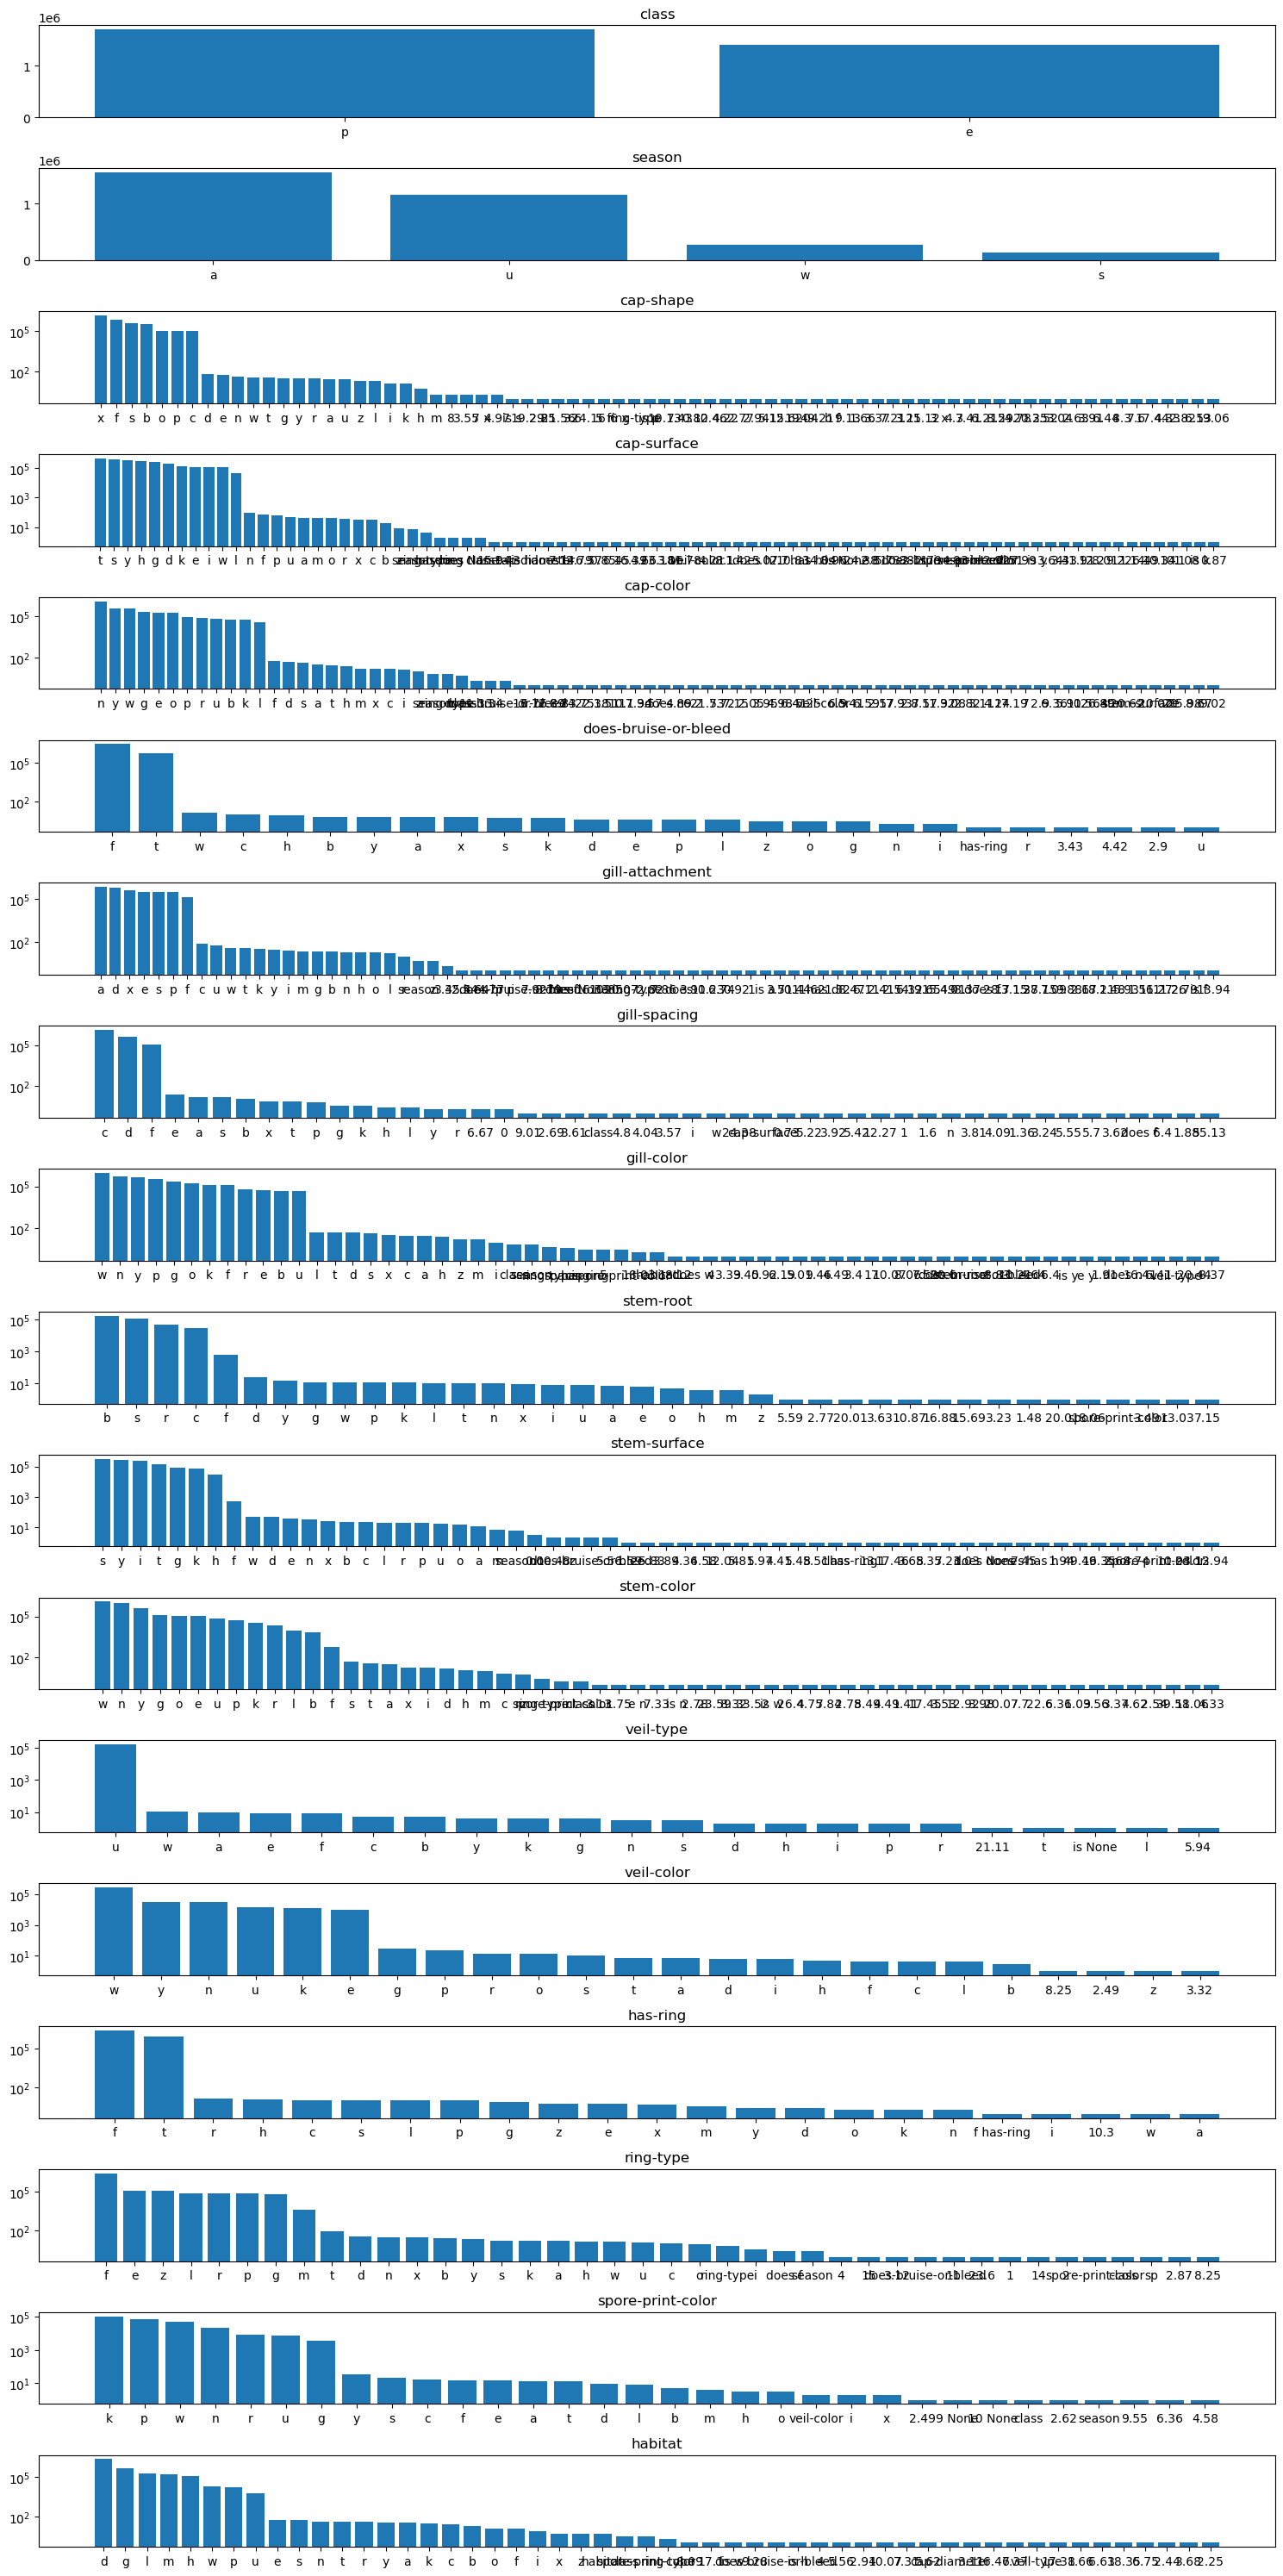

In [9]:
fig, ax = plt.subplots(18,1, figsize=(15, 30))
ax = ax.flatten()

for idx, c in enumerate(column_categorical):
    counts = data_train[c].value_counts()

    ax[idx].bar(counts.index, counts.values)
    ax[idx].set_title(c)
    # log scale cuz the rarer classes are invisible otherwise
    if c not in ["class", "season"]:
        ax[idx].set_yscale("log")


plt.tight_layout()
plt.show()

# Data Cleaning
- Classes with > 50% of their data missing might not be useful

In [10]:
missing_values_df = pd.DataFrame()
missing_values_df["# Missing"] = data_train.isnull().sum()
missing_values_df["% Missing"] = missing_values_df["# Missing"] / len(data_train) * 100
display(missing_values_df)

column_drop = ["id", "stem-root", "stem-surface", "veil-type", "veil-color", "spore-print-color", 'gill-spacing',]
column_reduced_categorical = ['class','season', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment',  'gill-color',
                       'stem-color',  'has-ring', 'ring-type', 'habitat']

data_merged = data_merged.drop(columns=column_drop)

,# Missing,% Missing
id,0,0.000000
class,0,0.000000
cap-diameter,4,0.000128
cap-shape,40,0.001283
cap-surface,671023,21.528227
cap-color,12,0.000385
does-bruise-or-bleed,8,0.000257
gill-attachment,523936,16.809280
gill-spacing,1258435,40.373988
gill-color,57,0.001829


- Some classes have tons of categories which are barely used (only very few elements) => maybe group some of them into a "others" bin?

In [11]:
num_unqiue_list = []
for column in column_reduced_categorical:
    num_unqiue_list.append(data_merged[column].nunique())

num_unique_cat_df = pd.DataFrame(data=num_unqiue_list, index=column_reduced_categorical, columns=["# Unique Categories Original"])

threshold = 100
for col in column_reduced_categorical:
    value_counts = data_merged[col].value_counts()
    test = value_counts[value_counts < threshold].index
    data_merged[col] = data_merged[col].apply(lambda x: "others" if x in test else x)

num_unqiue_list = []
for column in column_reduced_categorical:
    num_unqiue_list.append(data_merged[column].nunique())

num_unique_cat_df["# Unique Categories New"] = num_unqiue_list
print(data_merged.info(memory_usage='deep'))
print(data_train.info(memory_usage='deep'))
print(data_test.info(memory_usage='deep'))

num_unique_cat_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5194909 entries, 0 to 5194908
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   class                 object 
 1   cap-diameter          float64
 2   cap-shape             object 
 3   cap-surface           object 
 4   cap-color             object 
 5   does-bruise-or-bleed  object 
 6   gill-attachment       object 
 7   gill-color            object 
 8   stem-height           float64
 9   stem-width            float64
 10  stem-color            object 
 11  has-ring              object 
 12  ring-type             object 
 13  habitat               object 
 14  season                object 
 15  train_test            bool   
dtypes: bool(1), float64(3), object(12)
memory usage: 3.0 GB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3116945 entries, 0 to 3116944
Data columns (total 23 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id 

,# Unique Categories Original,# Unique Categories New
class,2,2
season,4,4
cap-shape,108,8
cap-surface,114,15
cap-color,109,13
does-bruise-or-bleed,29,3
gill-attachment,117,9
gill-color,86,13
stem-color,88,14
has-ring,26,3


In [12]:

del data_train
del data_test

In [ ]:
imputer_numerical = SimpleImputer(strategy='mean')
data_merged[column_numerical] = imputer_numerical.fit_transform(data_merged[column_numerical])

imputer_categorical = SimpleImputer(strategy='most_frequent')
data_merged[column_reduced_categorical] = imputer_categorical.fit_transform(data_merged[column_reduced_categorical])

encoder_onehot= OneHotEncoder(handle_unknown='ignore', sparse_output=False)
data_merged_encoded = pd.DataFrame(encoder_onehot.fit_transform(data_merged[column_reduced_categorical]), columns=encoder_onehot.get_feature_names_out(), index=data_merged.index)


data_merged = pd.concat([data_merged[column_numerical], data_merged_encoded, data_merged[["train_test"]]], axis=1)

data_merged

